In [ ]:
import os
import numpy as np
import torch
import sys

from matplotlib import pyplot as plt
from matplotlib import colors
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
import cmcrameri.cm as cmc

%matplotlib inline
plt.style.use('/home/beams/AILEENLUO/stylesheet.mplstyle')

sys.path.append('..')
from data import PtychographyDataset

In [2]:
data_path = '/scratch/aileenluo/ptycho-vit/data/eagle_dp.hdf5'
dataset = PtychographyDataset(data_path)

In [3]:
diff_amp, amp_patch, ph_patch, probe, _probe_pos, norm, scale = dataset[13545]

In [6]:
probe_intensity = torch.fft.fftshift(torch.fft.fft2(probe), dim=(-2, -1))
probe_intensity = (probe_intensity.abs()**2).sum(1)[0]
probe_intensity.shape

torch.Size([512, 512])

In [9]:
probe_intensity = (probe_intensity / norm) * scale

[]

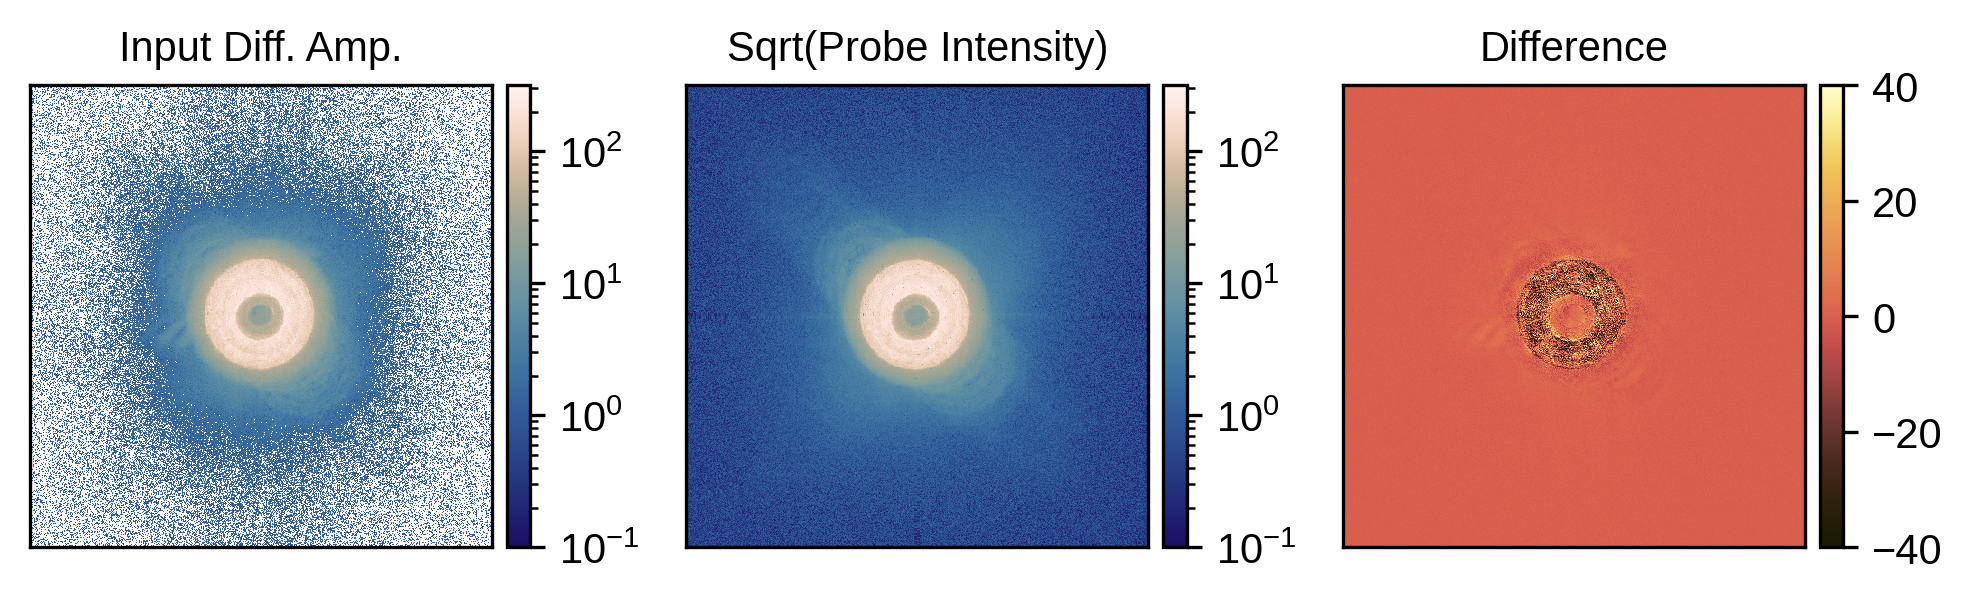

In [ ]:
f, ax = plt.subplots(figsize=(8, 2), ncols=3)

im0 = ax[0].imshow(diff_amp.squeeze(), interpolation='none', norm=colors.LogNorm(vmin=0.1, vmax=316), cmap=cmc.lapaz)
divider = make_axes_locatable(ax[0])
cax = divider.append_axes('right', size='5%', pad=0.05)
f.colorbar(im0, cax=cax, orientation='vertical')
ax[0].set_title('Input Diff. Amp.')
ax[0].set_xticks([])
ax[0].set_yticks([])

im1 = ax[1].imshow(torch.sqrt(probe_intensity), interpolation='none', norm=colors.LogNorm(vmin=0.1, vmax=316), cmap=cmc.lapaz)
divider = make_axes_locatable(ax[1])
cax = divider.append_axes('right', size='5%', pad=0.05)
f.colorbar(im1, cax=cax, orientation='vertical')
ax[1].set_title('Sqrt(Probe Intensity)')
ax[1].set_xticks([])
ax[1].set_yticks([])

im2 = ax[2].imshow(diff_amp.squeeze()-torch.sqrt(probe_intensity), interpolation='none', vmin=-40, vmax=40, cmap=cmc.lajolla)
divider = make_axes_locatable(ax[2])
cax = divider.append_axes('right', size='5%', pad=0.05)
f.colorbar(im2, cax=cax, orientation='vertical')
ax[2].set_title('Difference')
ax[2].set_xticks([])
ax[2].set_yticks([])
